# L1.16 — CNS: surveillance

**Level 1 · Core · 30 minutes**

**Goal.** You know what the separation logic reads.

**Check at the end.** You can say why "absent" is different from "old".

> Level 1 uses no simulation loop. You call each module directly.
>
> The text in this course obeys ASD-STE100 Simplified Technical English.

## 1. The last layer, and the shortest one

Navigation made a `Message`. Communication decided whether and when it arrived. Surveillance answers
the last question:

> Given what this receiver holds, what does it believe about that aircraft **now**?

```python
class SurveillanceModel:
    def perceived(state, receiver, source, t_now) -> AircraftState | None: ...
```

One model ships. `LastKnown` is **hold-as-is**: the belief is exactly the last delivered message,
unchanged. It does not extrapolate.

That is a decision, not a simplification. Dead-reckoning a stale message forward assumes the source
kept flying straight — and that assumption is wrong exactly when the source has just started to
manoeuvre, which is the moment you most need to be right.

In [1]:
%matplotlib inline
import dataclasses

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.grid"] = False
BLUE, RED, GREY, GREEN, ORANGE = "#1f77b4", "#d62728", "#7f7f7f", "#2ca02c", "#ff7f0e"

from opencdarr import M600, create_aircraft, generator, geo, root_seed_sequence
from opencdarr.cns import Comm, GnssNavigation, LastKnown, age

FLEET = [create_aircraft(M600, id=name, lat=52.0, lon=4.0 + 0.005 * k, trk=90.0, gs=12.0,
                         pos_ci95=10.0, vel_ci95=1.0)
         for k, name in enumerate(("OWN", "INT"))]
NAV, SEE = GnssNavigation(), LastKnown()


def stream(seed: int):
    return generator(root_seed_sequence(seed))


comm = Comm(reception_prob=0.7, latency=0.3)
state = comm.initial_state()
rng = stream(4)

print(f"{'t [s]':>7}{'OWN believes INT is at':>26}{'age [s]':>10}")
for k in range(8):
    t = float(k)
    msgs = [NAV.measure(NAV.initial_state(), ac, t, rng) for ac in FLEET]
    state = comm.step(state, msgs, FLEET, t, rng)
    seen = SEE.perceived(state, receiver="OWN", source="INT", t_now=t)
    how_old = age(state, receiver="OWN", source="INT", t_now=t)
    where = "nothing yet" if seen is None else f"{seen.lat:.5f}, {seen.lon:.5f}"
    print(f"{t:>7.0f}{where:>26}{'-' if how_old is None else f'{how_old:.1f}':>10}")

  t [s]    OWN believes INT is at   age [s]
      0               nothing yet         -
      1         52.00000, 4.00490       1.0
      2         52.00008, 4.00491       1.0
      3         51.99993, 4.00509       1.0
      4         52.00004, 4.00501       1.0
      5         51.99998, 4.00496       1.0
      6         51.99999, 4.00494       1.0
      7         52.00001, 4.00506       1.0


## 2. Absent is not old

`perceived` returns `None` before the first message from that source arrives. It does not return a
stale state, and it does not return the truth.

That distinction matters to the runner. An aircraft with `None` for a neighbour is **dropped from
its perceived traffic** — it does not know that neighbour exists, so it cannot detect a conflict
with it. An aircraft with an old state does know, and acts on information that is wrong.

The two produce different behaviour, so they must be different values:

| Return | Meaning | What the separation logic does |
| --- | --- | --- |
| `None` | No contact yet. | Ignores that aircraft entirely. |
| An `AircraftState` | Contact, possibly old. | Acts on it as if it were current. |

`age(state, receiver, source, t_now)` reports how stale the belief is, and it too returns `None`
before first contact. It is instrumentation: no surveillance model changes it, because the age is a
property of `t_meas` and not of what the model does with the message.

In [2]:
late = Comm(reception_prob=0.25, latency=0.5)
state = late.initial_state()
rng = stream(11)

first_contact = None
for k in range(30):
    t = float(k)
    msgs = [NAV.measure(NAV.initial_state(), ac, t, rng) for ac in FLEET]
    state = late.step(state, msgs, FLEET, t, rng)
    if SEE.perceived(state, "OWN", "INT", t) is not None:
        first_contact = t
        break

print(f"a poor link: OWN hears INT for the first time at t = {first_contact:.0f} s")
print(f"before that:  perceived -> None,  age -> None")
print(f"\nboth halves of the pair, at t = {first_contact:.0f} s:")
for receiver, source in (("OWN", "INT"), ("INT", "OWN")):
    seen = SEE.perceived(state, receiver, source, first_contact)
    print(f"  {receiver} about {source}: "
          f"{'nothing yet' if seen is None else 'has a fix'}   "
          f"age {age(state, receiver, source, first_contact)}")

a poor link: OWN hears INT for the first time at t = 3 s
before that:  perceived -> None,  age -> None

both halves of the pair, at t = 3 s:
  OWN about INT: has a fix   age 1.0
  INT about OWN: nothing yet   age None


## 3. The age sawtooth

Every delivery resets the age to the message's latency. Between deliveries it grows at one second
for each second. So a plot of the age is a sawtooth, and the **height of the teeth** is what a
resolver has to tolerate.

Report the worst tooth, not the mean. A resolver that is fine at the mean age and fails at the worst
one is a resolver that fails.

In [3]:
def age_history(comm, n: int = 300, dt: float = 0.25, tx_interval: float = 1.0, seed: int = 5):
    """The age of OWN's belief about INT, sampled every dt."""
    state = comm.initial_state()
    rng = stream(seed)
    out = []
    for k in range(int(n / dt)):
        t = k * dt
        due = abs(t / tx_interval - round(t / tx_interval)) < 1e-9
        msgs = [NAV.measure(NAV.initial_state(), ac, t, rng) for ac in FLEET] if due else []
        state = comm.step(state, msgs, FLEET, t, rng)
        out.append((t, age(state, "OWN", "INT", t)))
    return out


CHANNELS = {
    "perfect": Comm(),
    "p=0.9, no delay": Comm(reception_prob=0.9),
    "p=0.9, 0.4 s delay": Comm(reception_prob=0.9, latency=0.4),
    "p=0.5, 0.4 s delay": Comm(reception_prob=0.5, latency=0.4),
}

print(f"{'channel':<22}{'mean age':>11}{'median':>10}{'99th pct':>11}{'worst':>9}")
histories = {}
for label, channel in CHANNELS.items():
    rows = age_history(channel)
    ages = np.array([a for _, a in rows if a is not None])
    histories[label] = rows
    print(f"{label:<22}{ages.mean():>11.2f}{np.median(ages):>10.2f}"
          f"{np.percentile(ages, 99):>11.2f}{ages.max():>9.2f}")

channel                  mean age    median   99th pct    worst
perfect                      0.38      0.38       0.75     0.75
p=0.9, no delay              0.51      0.50       2.26     3.75
p=0.9, 0.4 s delay           1.01      1.00       2.77     4.25
p=0.5, 0.4 s delay           1.80      1.25       6.77     9.25


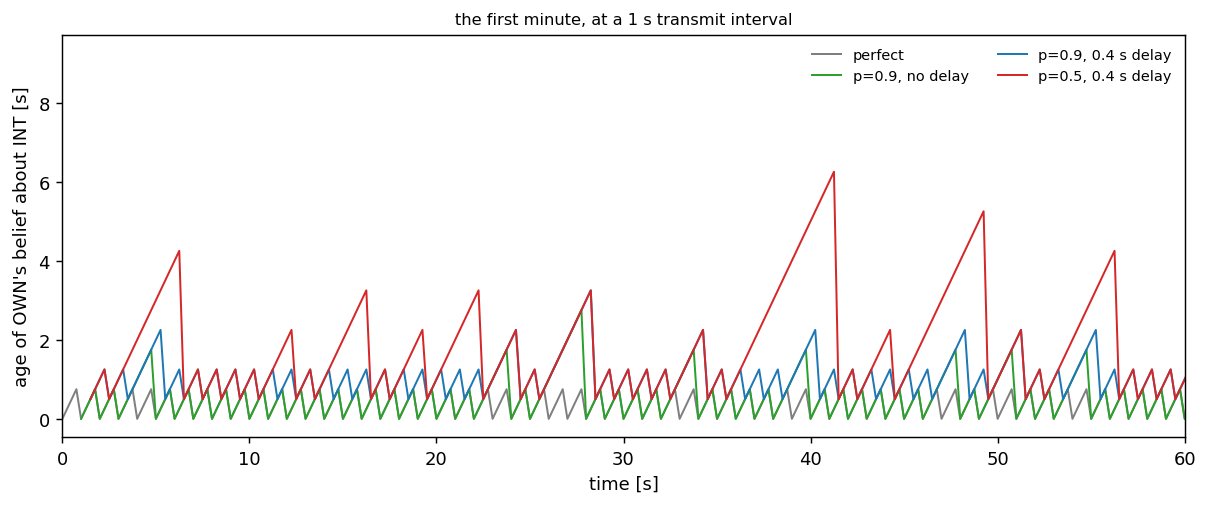

In [4]:
fig, ax = plt.subplots(figsize=(9.4, 4.0))
for (label, rows), colour in zip(histories.items(), (GREY, GREEN, BLUE, RED)):
    t = np.array([r[0] for r in rows])
    a = np.array([np.nan if r[1] is None else r[1] for r in rows])
    ax.plot(t, a, lw=1.1, color=colour, label=label)
ax.set_xlim(0, 60)
ax.set_xlabel("time [s]")
ax.set_ylabel("age of OWN's belief about INT [s]")
ax.set_title("the first minute, at a 1 s transmit interval", fontsize=9)
ax.legend(frameon=False, fontsize=8, ncols=2)
fig.tight_layout()

## 4. Where this sits in the stack

`CNS` is the object that runs all three layers in order. You do not build it yourself — `run_fleet`
does, from the three models you pass it — but knowing the order explains every result in Level 2.

```
navigation.evolve   ->  the nav layer ages (outages, drift)
navigation.measure  ->  each firing aircraft makes its own noisy fix
communication.step  ->  one channel step for the whole tick
surveillance        ->  each aircraft's Perception is built
```

Three properties of that order are load-bearing:

1. **All the navigation draws happen first**, in a fixed aircraft order. So what one aircraft draws
   does not depend on which other aircraft happened to transmit this tick.
2. **The channel steps once for the whole tick**, not once per link.
3. **Surveillance draws nothing.** It is a lookup. All the randomness is already spent.

Every firing aircraft therefore transmits from a snapshot taken **before** any decision this tick.
Nobody reacts to a manoeuvre that has not been broadcast yet.

With no `communication` model, each aircraft reads every other aircraft's current broadcast directly
— perfect delivery. With one, it reads `perceived` per directed link, which is where `None` and
staleness enter.

In [5]:
from opencdarr.cns import CNS, CnsStreams

stack = CNS(navigation=GnssNavigation(), communication=Comm(reception_prob=0.8, latency=0.3),
            surveillance=LastKnown())
cns_state = stack.initial_state(len(FLEET))   # always through the stack, never by hand
streams = CnsStreams(nav=stream(1), comm=stream(2))

for k in range(4):
    t = float(k)
    cns_state, perceptions = stack.sense(FLEET, firing=[0, 1], t=t, cns=cns_state, streams=streams)
    for i, view in sorted(perceptions.items()):
        others = [ac.id for ac in view.traffic]
        print(f"t = {t:.0f}  {FLEET[i].id} sees itself at "
              f"({view.own.lat:.5f}, {view.own.lon:.5f}) and traffic {others or 'none'}")

t = 0  OWN sees itself at (52.00003, 4.00002) and traffic none
t = 0  INT sees itself at (52.00002, 4.00505) and traffic none
t = 1  OWN sees itself at (52.00001, 4.00002) and traffic ['INT']
t = 1  INT sees itself at (51.99999, 4.00496) and traffic ['OWN']
t = 2  OWN sees itself at (51.99999, 4.00000) and traffic ['INT']
t = 2  INT sees itself at (51.99999, 4.00500) and traffic ['OWN']
t = 3  OWN sees itself at (51.99993, 3.99984) and traffic ['INT']
t = 3  INT sees itself at (52.00001, 4.00501) and traffic ['OWN']


## Do it yourself

1. Set `reception_prob=1.0` and `latency=0.0`. Check that the age is zero at every tick.
2. Set the transmit interval to 4 s in `age_history`. Compare the worst tooth.
3. Give the two directions different reception probabilities. Compare `age("OWN", "INT")` with
   `age("INT", "OWN")`.
4. Write a surveillance model that dead-reckons the held state forward by its age. Say when it would
   be worse than `LastKnown`.

## Check

1. Why is "absent" different from "old"? What does the runner do differently for each?
2. Why does `LastKnown` not extrapolate?
3. Surveillance draws no randomness. Why does that matter for a comparison between two runs?

## Next

`L1.17 — Random numbers and repeatability`. Every layer above draws. Next you make sure those draws
are reproducible and independent.